# Laboratorio 4 - Aprendizaje de Máquina
### Integrantes:
- Zair Samuel Montoya Bello - 202321067
- Tomas Hernandez Faura - 202320326

## Introducción

## 1. Importación de librerías

In [11]:
try:
    import pandas as pd
    print(f"Pandas {pd.__version__} cargado correctamente.")
    import numpy as np
    print(f"Numpy {np.__version__} cargado correctamente.")
    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import seaborn as sns
    print("Matplotlib y Seaborn cargados correctamente.")
    from sklearn.preprocessing import RobustScaler
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
    from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score
    from sklearn.neighbors import NearestNeighbors
    from scipy.cluster.hierarchy import dendrogram, linkage
    print("Librerías de sklearn y scipy cargadas correctamente.")
except ImportError as e:
    print(f"Dependencia no encontrada: {e}. Ejecuta la siguiente celda para instalarlas.")


Pandas 3.0.2 cargado correctamente.
Numpy 2.4.4 cargado correctamente.
Matplotlib y Seaborn cargados correctamente.
Librerías de sklearn y scipy cargadas correctamente.


En el caso de que no cuente con las librerias necesarias, puede descargarlas directamente ejecutando la siguiente celda, en caso de que las librerias se hayan cargado correctamente, puede saltarse la ejecucion de esta.

In [12]:
# Instalar las librerías necesarias
#%pip install pandas numpy matplotlib seaborn scikit-learn scipy openpyxl

## 2. Exploración de los datos

Iniciamos cargando el dataset y realizando un análisis de exploracion para identificar problemas de calidad, entender la distribución de las variables y las relaciones entre ellas. Esta etapa es fundamental antes de cualquier decisión de preparación de datos, ya que los factores que identifiquemos aquí justificaran cada paso del preprocesamiento.

In [13]:
datos_raw = pd.read_csv("data/Datos_VuelaAlpes.csv")
datos = datos_raw.copy()

print(f"Forma del dataset: {datos.shape}")
print(f"\nPrimeras filas:")
datos.head()


Forma del dataset: (10000, 23)

Primeras filas:


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,119496,Male,Loyal Customer,29,Business travel,Business,814,3,3,3,...,4,4,4,2,5,4,4,4,9,6.0
1,60419,Male,Loyal Customer,54,Business travel,Business,2913,4,4,4,...,4,4,4,4,4,4,4,4,26,9.0
2,9671,Male,Loyal Customer,52,Business travel,Eco,277,4,5,5,...,4,4,4,4,4,3,4,4,68,42.0
3,59115,Female,Loyal Customer,17,Personal Travel,Eco,1744,3,0,3,...,1,4,4,2,5,4,5,4,7,39.0
4,75857,Female,Loyal Customer,30,Personal Travel,Eco,1440,3,4,3,...,3,3,5,5,4,5,4,3,0,0.0


El dataset contiene los registros de pasajeros con variables demográficas, características del vuelo y calificaciones de servicio. Ahora, revisaremos los tipos de datos y sus estadisticas para tener una primera impresión de las variables.

In [14]:
print("Tipos de datos:")
print(datos.dtypes)

Tipos de datos:
id                                     int64
Gender                                   str
Customer Type                            str
Age                                    int64
Type of Travel                           str
Class                                    str
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64
Departure Delay in Minutes             

El dataset contiene variables numéricas (edad, distancia, retrasos, calificaciones 0–5) y variables categóricas (género, tipo de cliente, tipo de viaje, clase, satisfacción). Para el clustering usaremos únicamente las variables numéricas, lo que evita la expansión del espacio al crear muchas nuevas columnas por OneHotEncoding y permite una interpretación más directa de los grupos. Ahora, vamos a seguir con la descripcion de las distribuciones de las variables y su informacion adicional, para poder identificar patrones anomalos y hacernos una idea de los valores nulos.

In [15]:
datos.describe()

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,9975.000000
mean,64983.058500,39.404300,1196.044800,2.734700,3.074000,2.762600,3.002800,3.215200,3.234500,3.431300,3.361900,3.391000,3.34440,3.635800,3.291700,3.643700,3.281200,14.86020,15.215439
std,37610.205164,15.072364,1000.590808,1.328718,1.520511,1.394287,1.283182,1.324486,1.350293,1.314935,1.329099,1.287123,1.31809,1.184271,1.263951,1.183085,1.311068,36.78467,37.370561
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.00000,1.000000,1.000000,1.000000,1.000000,0.00000,0.000000
25%,32452.000000,27.000000,416.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.00000,3.000000,2.000000,3.000000,2.000000,0.00000,0.000000
50%,64815.500000,40.000000,846.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.00000,4.000000,3.000000,4.000000,3.000000,0.00000,0.000000
75%,97470.000000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.00000,5.000000,4.000000,5.000000,4.000000,13.00000,13.000000
max,129879.000000,80.000000,4963.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,930.00000,952.000000


Tal como podemos ver, las estadísticas descriptivas muestran que las variables tienen rangos muy distintos entre sí: `Flight Distance` puede superar los 4000 km, mientras que las calificaciones van de 0 a 5. Ademas, los retrasos presentan valores máximos muy alejados del tercer cuartil, anticipando la presencia de outliers significativos.

### 2.1 Valores nulos

Ahora, continuaremos con la busqueda de valores nulos para cada una de las columnas para saber que porcentaje de cada variable tiene valores nulos para determinar la accion que tomaremos para asegurar la completitud de los datos.

In [16]:
nulos = datos.isnull().sum()
nulos_pct = (datos.isnull().mean() * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_pct})
resumen_nulos = resumen_nulos[resumen_nulos['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False)
print("Columnas con valores nulos:")
print(resumen_nulos)

Columnas con valores nulos:
                          Nulos  Porcentaje (%)
Arrival Delay in Minutes     25            0.25


Como podemos ver, la columna `Arrival Delay in Minutes` presenta una pequeña cantidad de valores nulos, al ser un porcentaje bajo, decidimos imputar con la mediana en lugar de eliminar filas, conservando la mayor cantidad de registros posible. La mediana es preferible a la media debido a que es robusta ante los outliers presentes en esta variable.

### 2.2 Valores duplicados

Continuaremos con la busqueda de filas duplicadas para permitirnos asegurar la unicidad en nuestro dataset.

In [17]:
duplicados = datos.duplicated().sum()
print(f"Filas duplicadas: {duplicados} ({duplicados/len(datos)*100:.2f}%)")

Filas duplicadas: 0 (0.00%)


No se encontraron filas completamente duplicadas en el dataset, por lo que no es necesario tomar ninguna acción sobre este aspecto. Sin embargo, haremos la revision de que los id no esten duplicados para asegurarnos que el dataset es coherente.

In [18]:
duplicados_id = datos['id'].duplicated().sum()
print(f"IDs duplicados: {duplicados_id} ({duplicados_id/len(datos)*100:.2f}%)")

IDs duplicados: 0 (0.00%)


Como podemos ver, tampoco hay IDs duplicados, por lo que podemos asegurar la unicidad de nuestro dataset.

### 2.3 Distribución de variables numéricas

Ahora, continuaremos con el analisis de la distribucion de las variables numericas, a pesar de que nos podemos hacer una idea de las distribuciones de las variables gracias a el datos.describe() que corrimos anteriormente, revisar las distribuciones de manera grafica claramente nos permitira encontrar anomalias o patrones dentro de nuestro dataset que nos permitiran tener un mayor conocimiento acerca del mismo y nos permitira analizar si es necesario aplicar algun tipo de limpieza a nuestros datos.

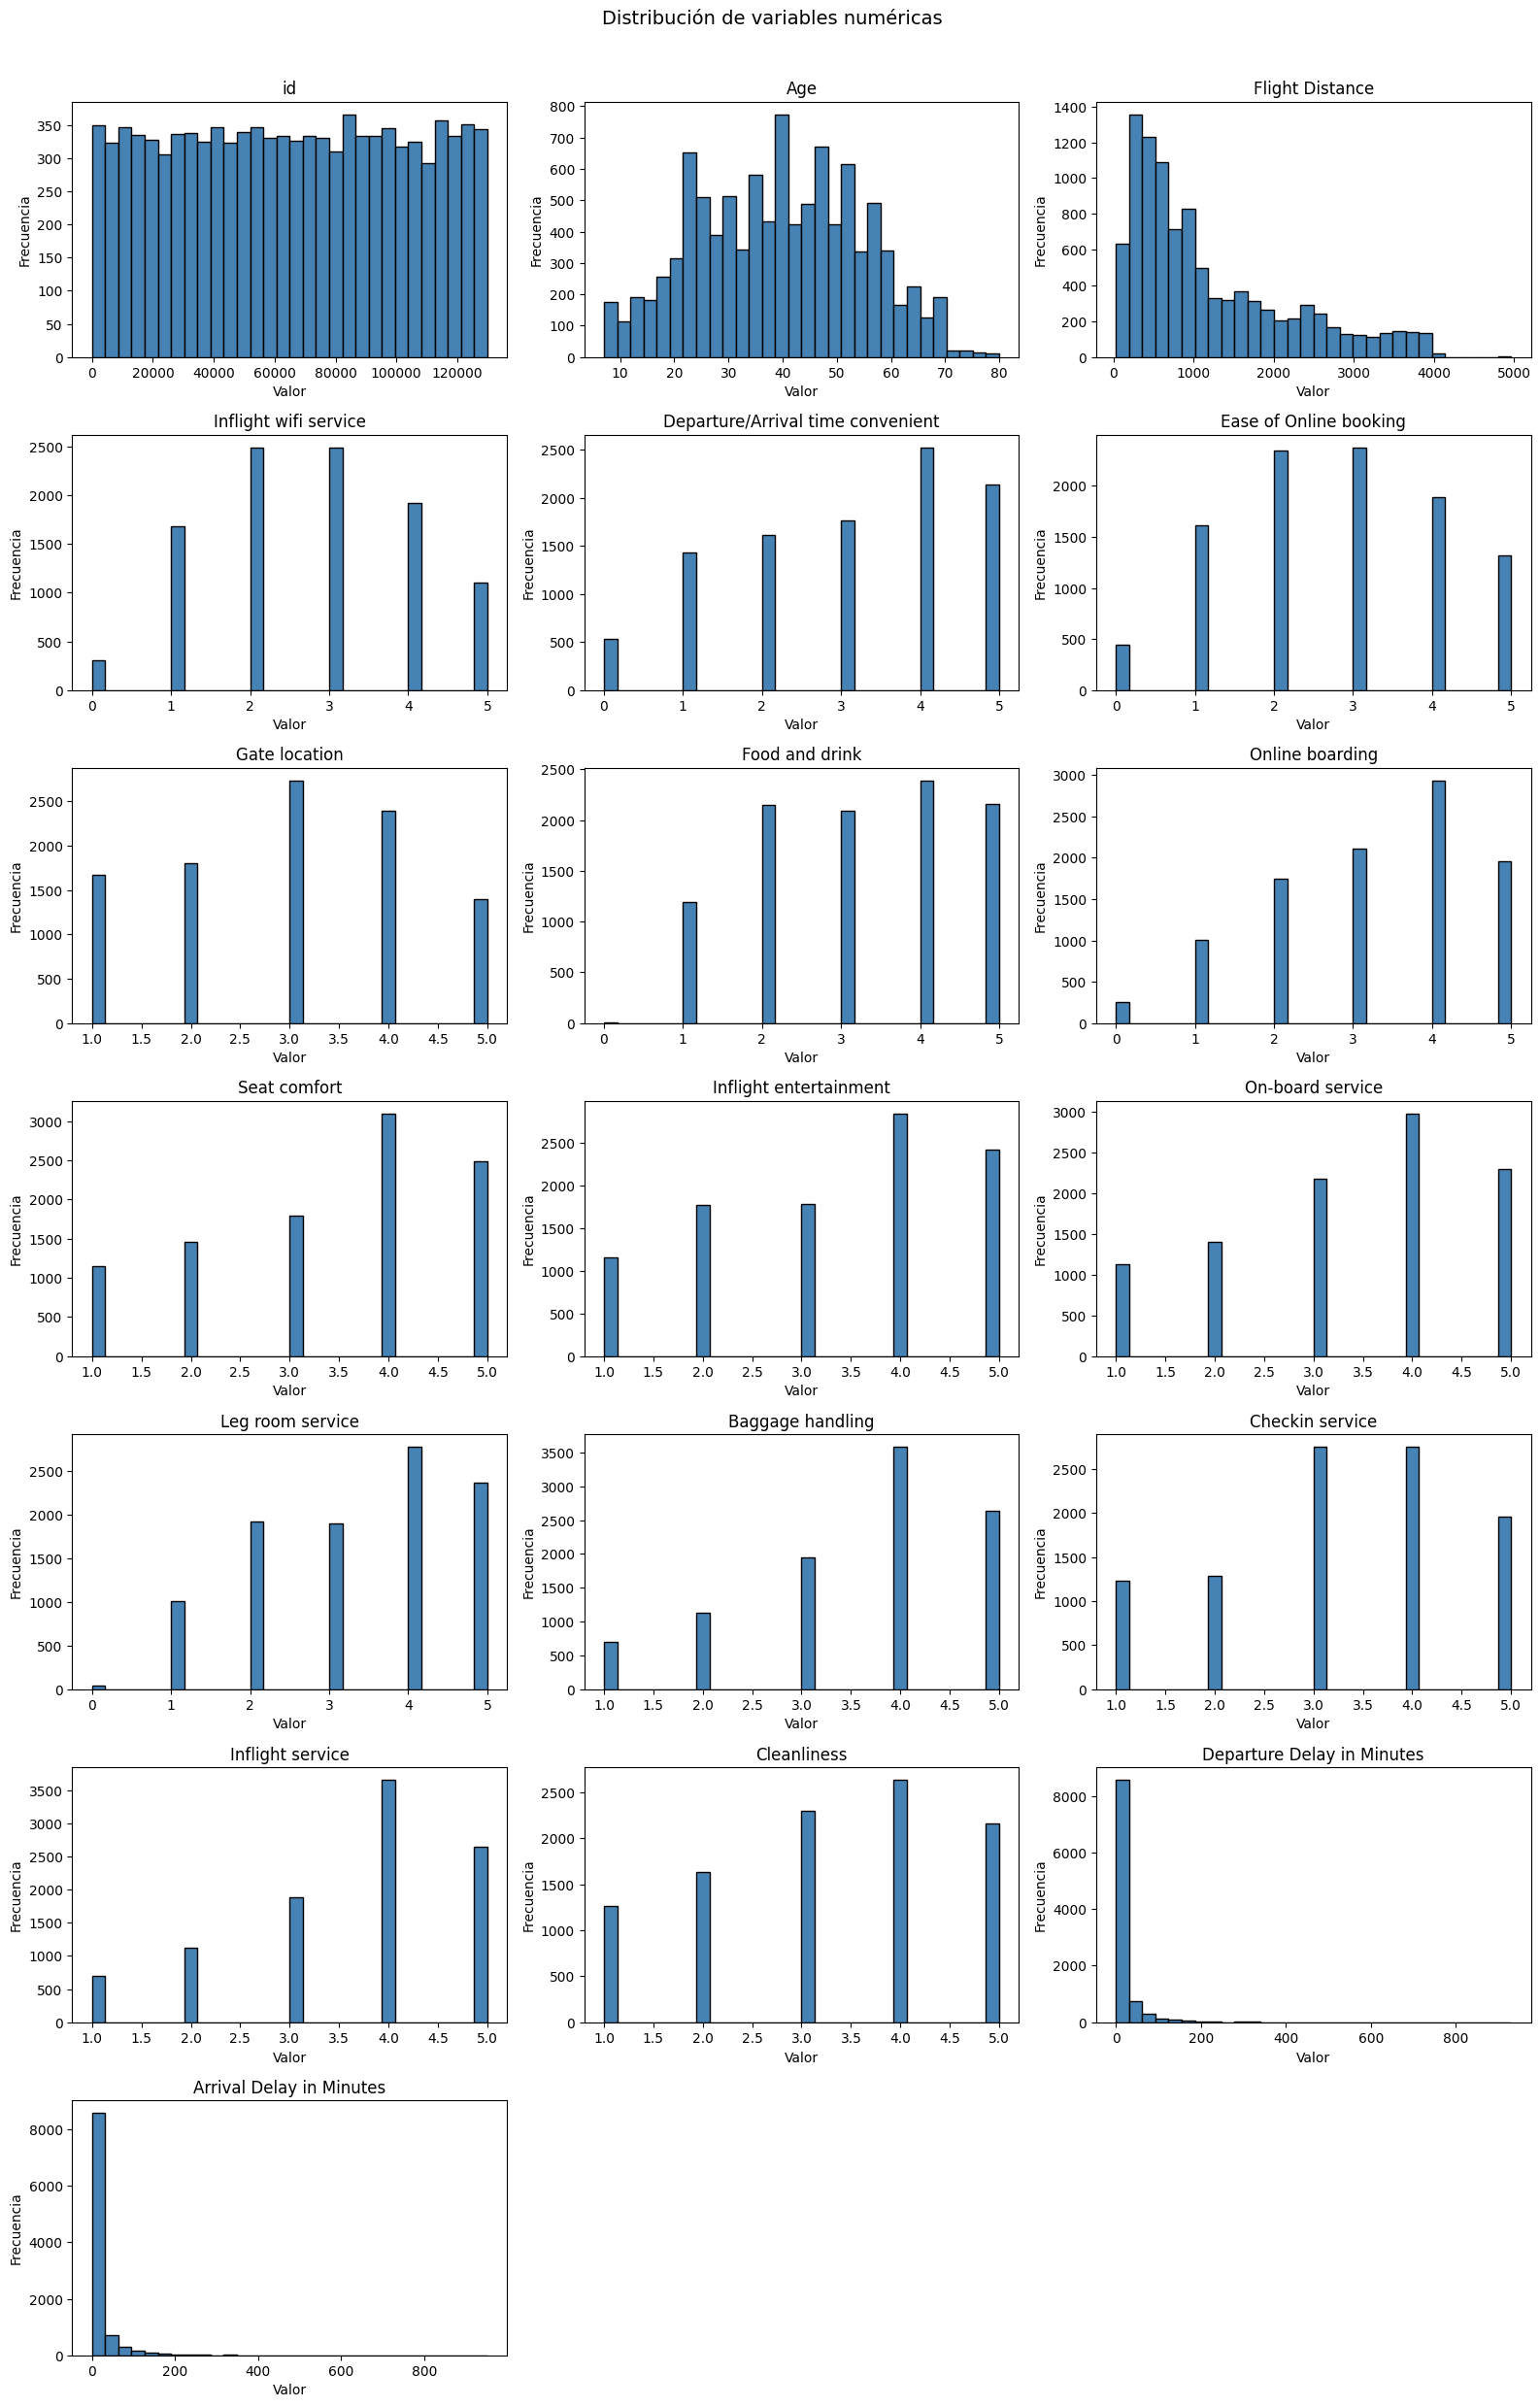

In [19]:
numeric_cols = datos.select_dtypes(include=['int64', 'float64']).columns.tolist()
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(datos[col].dropna(), bins=30, edgecolor='black', color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribución de variables numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Tal como podemos ver, las distribuciones muestran que las variables de calificación (0–5) presentan acumulación en los extremos, especialmente en 0 y 5, lo cual es esperable en encuestas de satisfacción. Ademas, las variables de retraso tienen distribuciones asimétricas con colas largas hacia la derecha, lo que confirma la necesidad de escalar antes de aplicar cualquier algoritmo basado en distancias.

### 2.4 Detección de valores atípicos

Ahora continuaremos con la deteccion de valores atipicos, haremos esto para analizar si es necesario hacer algun tipo de limpieza de valores atipicos.

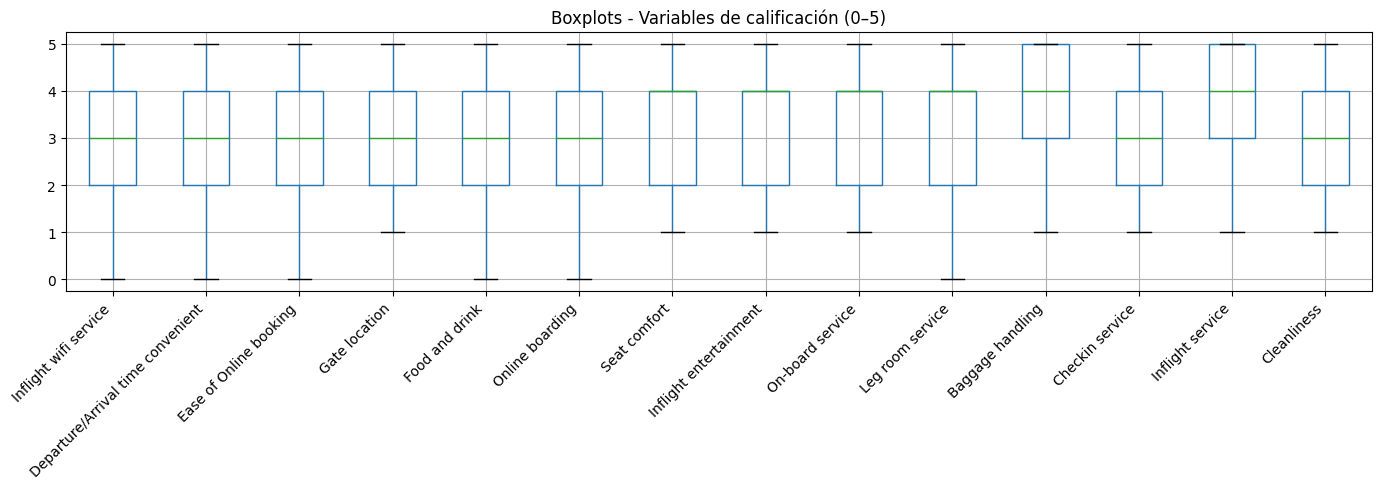

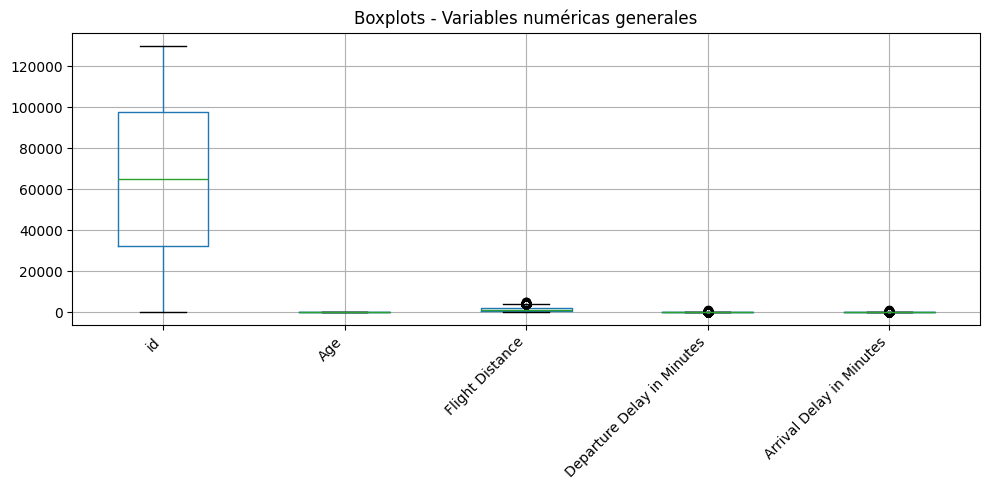

In [20]:
rating_cols = [col for col in numeric_cols if datos[col].max() <= 5 and datos[col].min() >= 0]
other_num_cols = [col for col in numeric_cols if col not in rating_cols]

if rating_cols:
    fig, ax = plt.subplots(figsize=(14, 5))
    datos[rating_cols].boxplot(ax=ax)
    ax.set_title('Boxplots - Variables de calificación (0–5)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

if other_num_cols:
    fig, ax = plt.subplots(figsize=(10, 5))
    datos[other_num_cols].boxplot(ax=ax)
    ax.set_title('Boxplots - Variables numéricas generales')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Tal como podemos ver, los boxplots confirman la presencia de outliers significativos en `Departure Delay in Minutes` y `Arrival Delay in Minutes`, con valores que superan varias veces el rango intercuartílico. Dado que estos valores son reales y no errores de captura, decidiremos conservarlos, su impacto se mitiga usando `RobustScaler` en la etapa de escalamiento, que es más robusto ante outliers que `StandardScaler` al basarse en la mediana y el IQR.

### 2.5 Correlaciones entre variables numéricas

Como nuestra ultima etapa de la exploracion de datos, graficaremos la matriz de correlaciones entre nuestras variables numericas, lo que nos dara informacion acerca de valores que esten muy relacionados o muy poco relacionados entre si para determinar que variables utilizar para nuestro modelo.

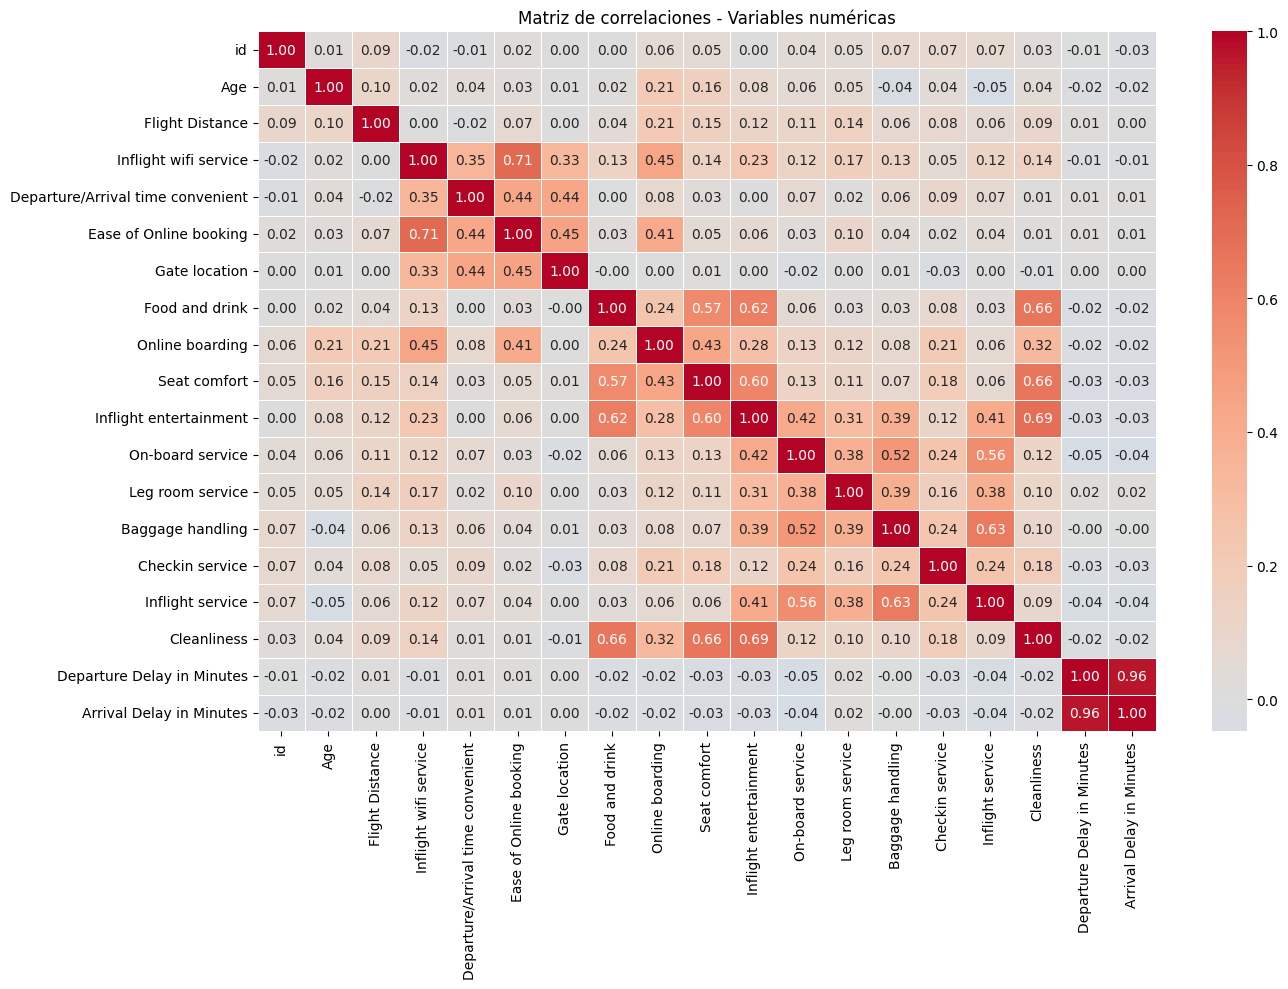

In [21]:
corr_matrix = datos[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Matriz de correlaciones - Variables numéricas')
plt.tight_layout()
plt.show()

Podemos ver que la matriz de correlaciones muestra que `Departure Delay in Minutes` y `Arrival Delay in Minutes` están correlacionadas con 0.96 entre sí, prácticamente midiendo lo mismo, y presentan correlaciones cercanas a cero con las variables de calificación. Esto confirma que no aportan información útil para caracterizar perfiles de pasajeros y justifica su exclusión del clustering.

Ademas, entre las variables de calificación se observan correlaciones moderadas a altas dentro de grupos temáticos: servicios a bordo como `Food and drink`, `Seat comfort`, `Inflight entertainment` y `Cleanliness` correlacionan entre 0.57 y 0.69, mientras que servicios de tripulación como `On-board service`, `Baggage handling` e `Inflight service` correlacionan entre 0.52 y 0.63. Esta redundancia se tendrá en cuenta en la selección de variables de la etapa de preparación. `Age` y `Flight Distance` presentan correlaciones bajas con todas las demás, confirmando que aportan información independiente y relevante para la segmentación.

### 2.6 Resumen de problemas de calidad identificados

Con base en el análisis exploratorio, se identificaron los siguientes hallazgos:

- **Valores nulos:** la columna `Arrival Delay in Minutes` presenta valores nulos (< 5% del total). Se imputarán con la mediana por ser robusta ante outliers.

- **Valores duplicados:** no se encontraron filas completamente duplicadas en el dataset.

- **Valores atípicos:** las variables de retraso presentan outliers significativos con colas largas. Al ser valores reales se conservan, y su efecto se controla con `RobustScaler`.

- **Rangos dispares:** variables como `Flight Distance`, `Age` y los retrasos tienen escalas muy distintas respecto a las calificaciones (0–5). El escalamiento es indispensable antes de aplicar cualquier algoritmo basado en distancias.

- **Correlaciones moderadas entre calificaciones:** varias variables de calificación presentan correlaciones entre sí (por ejemplo, `Inflight service` y `On-board service`), lo que es esperable en encuestas de satisfacción y no constituye un problema de calidad en sí mismo.

## 3. Preparación de los datos

Con base en los problemas identificados en la exploración, definimos la siguiente estrategia de preparación. Todas las decisiones se justifican en función de los algoritmos de clustering que vamos a aplicar, los cuales son sensibles a la escala y a los valores nulos.

### 3.1 Selección de variables y limpieza inicial

Para el clustering utilizaremos únicamente las **variables numéricas**, excluyendo:
- La columna **`id`**, debido a que no tiene relevancia para el clustering
- Las **variables categóricas** (`Gender`, `Customer Type`, `Type of Travel`, `Class`, `satisfaction`): incluirlas requeriría OneHotEncoding, lo que expandiría el espacio y dificultaría la interpretación de los grupos.

In [22]:
features_clustering = [
    'Age', 'Flight Distance',
    'Inflight wifi service', 'Online boarding', 'Seat comfort',
    'Inflight entertainment', 'On-board service', 'Leg room service',
    'Baggage handling', 'Cleanliness'
]
datos_num = datos[[f for f in features_clustering if f in datos.columns]]

print(f"Variables seleccionadas ({len(datos_num.columns)}):")
print(list(datos_num.columns))
print(f"\nShape: {datos_num.shape}")


Variables seleccionadas (10):
['Age', 'Flight Distance', 'Inflight wifi service', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Cleanliness']

Shape: (10000, 10)


Quedamos con 10 variables que cubren las dos dimensiones clave para VuelaAlpes: el perfil del pasajero (`Age`, `Flight Distance`) y las calificaciones de los servicios más relevantes del vuelo. Ademas, se excluyen los retrasos porque presentan distribuciones extremadamente asimétricas con outliers que distorsionan el espacio de distancias sin aportar datos útilel para caracterizar perfiles.

### 3.2 Imputación y escalamiento mediante pipeline

Seguimos con la construccion un pipeline que integra dos pasos en un único flujo reproducible:
- **Imputación con la mediana:** para manejar los valores nulos de `Arrival Delay in Minutes` de forma robusta ante outliers.
- **`RobustScaler`:** escala cada variable usando la mediana y el rango intercuartílico (IQR) en lugar de la media y la desviación estándar. Esto lo hace más resistente a los outliers presentes en las variables de retraso.

In [23]:
pipeline_prep = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

X = pipeline_prep.fit_transform(datos_num)
X_df = pd.DataFrame(X, columns=datos_num.columns)

print(f"Shape tras preprocesamiento: {X_df.shape}")
print(f"Valores nulos restantes: {X_df.isnull().sum().sum()}")
X_df.describe().round(3)

Shape tras preprocesamiento: (10000, 10)
Valores nulos restantes: 0


,Age,Flight Distance,Inflight wifi service,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Cleanliness
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,-0.025,0.264,-0.133,0.117,-0.284,-0.319,-0.304,-0.328,-0.182,0.141
std,0.628,0.753,0.664,0.675,0.657,0.665,0.644,0.659,0.592,0.656
min,-1.375,-0.614,-1.500,-1.500,-1.500,-1.500,-1.500,-2.000,-1.500,-1.000
25%,-0.542,-0.324,-0.500,-0.500,-1.000,-1.000,-1.000,-1.000,-0.500,-0.500
50%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.458,0.676,0.500,0.500,0.000,0.000,0.000,0.000,0.500,0.500
max,1.667,3.100,1.000,1.000,0.500,0.500,0.500,0.500,0.500,1.000


El preprocesamiento expande la tabla al mismo número de columnas (solo variables numéricas) y elimina todos los valores nulos. Las estadísticas descriptivas muestran que las variables están ahora en escalas comparables, centradas alrededor de la mediana, ahora los datos están listos para los algoritmos de clustering que aplicaremos.

## 4. Modelamiento

Continuaremos con la aplicacion tres algoritmos de agrupación con características distintas para comparar su comportamiento sobre este dataset. Cada algoritmo se caracteriza por tres aspectos de diseño: el **criterio de división** (cómo se organizan los grupos), la **separación entre grupos** (exclusiva, solapada o difusa) y la **medida de similitud** utilizada. Para cada uno realizaremos una búsqueda de hiperparámetros y construiremos un pipeline que integre el preprocesamiento y el modelo en un único flujo.

### Descripción de los algoritmos

#### K-Means (basado en centroides / por particiones)

K-Means es un algoritmo basado en centroides donde cada grupo está representado por un centroide, que corresponde a la media de los datos asociados al grupo. Un dato se asigna al grupo cuyo centroide es más cercano, usando la distancia euclideana como medida de similitud. El objetivo es minimizar la suma de distancias al cuadrado de cada punto a su centroide (inercia): $E = \sum_{i=1}^{k} \sum_{x \in G_i} \|x - c_i\|^2$.

En cuanto a sus aspectos de diseño: el criterio de división es **por particiones** (grupos al mismo nivel), la separación es **exclusiva** (cada pasajero pertenece a un solo grupo), y la medida de similitud es la **distancia euclideana**. El número de grupos k debe ser especificado por el usuario, dado que los resultados dependen de los centros iniciales, scikit-learn ejecuta el algoritmo `n_init=10` veces con diferentes inicializaciones y retiene la mejor agrupación según la inercia.

#### Clustering Jerárquico Aglomerativo

El algoritmo jerárquico aglomerativo sigue un esquema bottom-up: inicialmente trata cada dato como su propio grupo y en cada iteración fusiona el par de grupos más cercanos según un criterio de enlace. Una vez fusionados dos grupos no es posible rectificar en iteraciones posteriores. El resultado puede visualizarse en un **dendrograma** que permite analizar la estructura jerárquica completa y determinar el número de grupos cortando el árbol a la altura adecuada.

En cuanto a sus aspectos de diseño: el criterio de división es **jerárquico** (grupos anidados), la separación puede ser **solapada**, y la medida de similitud se basa en **distancias entre grupos** según el método de enlace. El enlace `ward` minimiza la varianza total intra-cluster en cada fusión, produciendo grupos compactos y de tamaño similar.

#### DBSCAN (basado en densidades)

DBSCAN identifica grupos como **regiones densas de objetos separadas por zonas de baja densidad**. Para cada punto determina su densidad local usando dos parámetros: `eps` (radio de la vecindad) y `min_samples` (mínimo de objetos en esa vecindad). Con estos parámetros clasifica cada punto como: **objeto núcleo** (tiene al menos `min_samples` vecinos en su radio), **objeto borde** (está en la vecindad de un núcleo pero no cumple el mínimo) u **objeto extremo/ruido** (no cumple ninguna de las condiciones anteriores, etiquetado como -1).

En cuanto a sus aspectos de diseño: el criterio de división es **por particiones** al mismo nivel, la separación es **exclusiva**, y la medida de similitud se basa en la **conectividad** (contigüidad por densidad). A diferencia de K-Means, no requiere especificar el número de grupos y puede detectar clusters de forma arbitraria, pero requiere que los datos presenten regiones densas claramente diferenciadas.

Ahora que ya definimos los algoritmos que implementaremos y su funcionamiento, iniciaremos con el proceso para implementar nuestro primer algoritmo, **K-Means**.

### 4.1 K-Means — Método del codo y análisis de Silhouette

k=2: Inercia=34023.76, Silhouette=0.2019
k=3: Inercia=30708.13, Silhouette=0.1713
k=4: Inercia=27816.26, Silhouette=0.1524
k=5: Inercia=25814.77, Silhouette=0.1536
k=6: Inercia=24572.47, Silhouette=0.1425
k=7: Inercia=23432.65, Silhouette=0.1381
k=8: Inercia=22614.50, Silhouette=0.1382
k=9: Inercia=21899.01, Silhouette=0.1374
k=10: Inercia=21218.21, Silhouette=0.1334


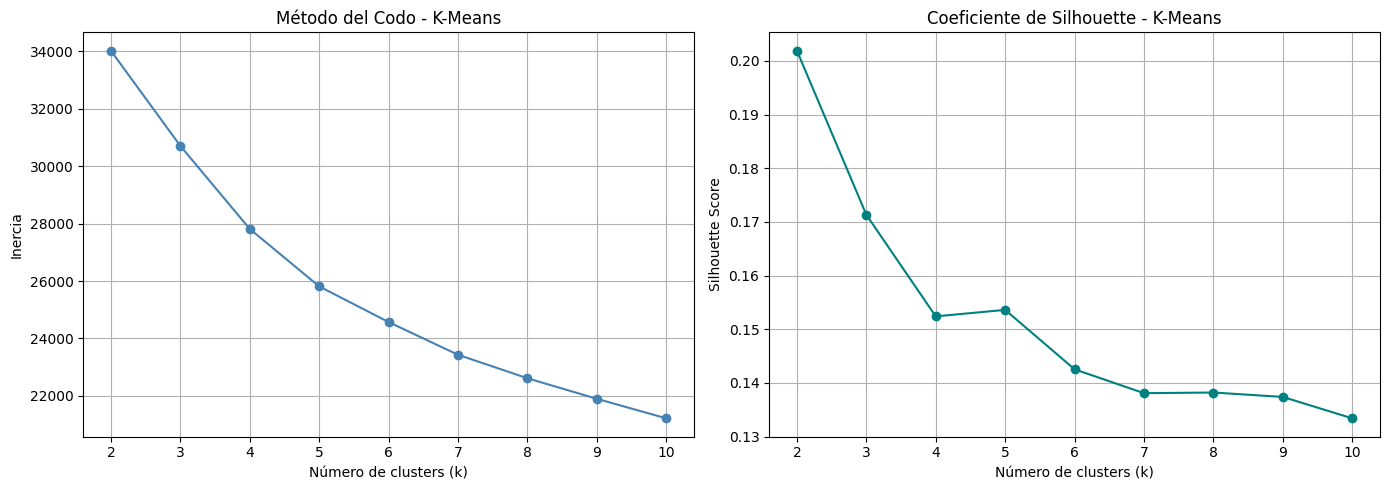

In [24]:
def elbow_plot(X, k_min=2, k_max=10):
    inertias = []
    sil_scores = []
    ks = range(k_min, k_max + 1)
    for k in ks:
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = km.fit_predict(X)
        inertias.append(km.inertia_)
        sil_scores.append(silhouette_score(X, labels))
        print(f"k={k}: Inercia={km.inertia_:.2f}, Silhouette={sil_scores[-1]:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(list(ks), inertias, marker='o', color='steelblue')
    axes[0].set_title('Método del Codo - K-Means')
    axes[0].set_xlabel('Número de clusters (k)')
    axes[0].set_ylabel('Inercia')
    axes[0].grid(True)

    axes[1].plot(list(ks), sil_scores, marker='o', color='teal')
    axes[1].set_title('Coeficiente de Silhouette - K-Means')
    axes[1].set_xlabel('Número de clusters (k)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()
    return list(ks), inertias, sil_scores

ks, inertias, sil_scores = elbow_plot(X, 2, 10)

Podemos ver que el metodo del codo muestra una caída pronunciada de la inercia hasta k=3, a partir del cual las ganancias son marginales. Ademas, la curva de Silhouette muestra que k=2 obtiene el valor más alto (0.2019), pero produce clusters muy desbalanceados con más del 90% de los puntos en un solo grupo, lo que no tiene utilidad analítica. Finalmente, k=3 obtiene el segundo Silhouette más alto (0.1713) con clusters bien equilibrados, siendo la configuración más adecuada tanto cuantitativamente como desde el punto de vista del negocio.

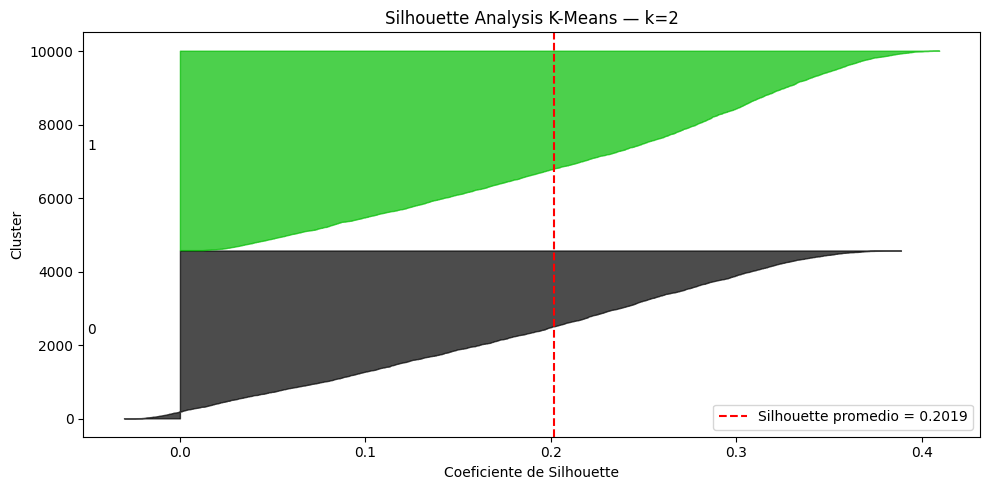

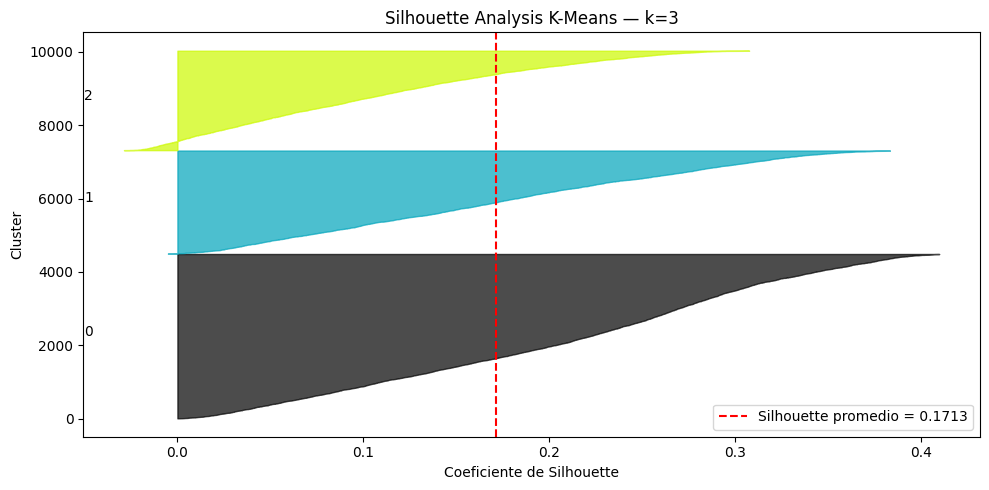

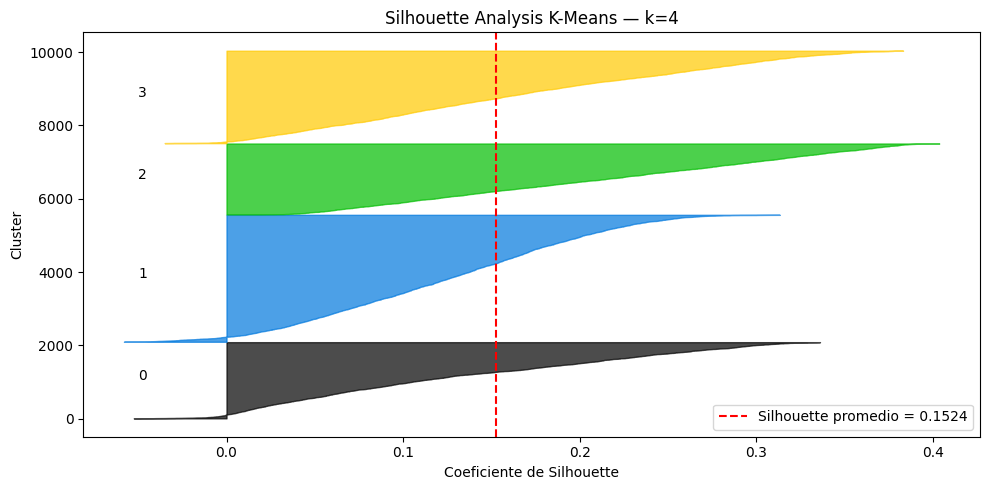

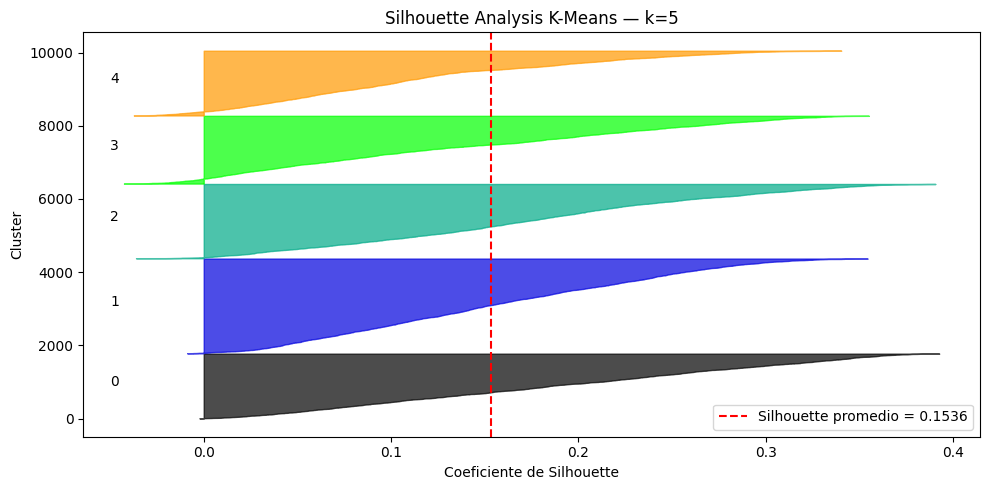

In [25]:
def silhouette_analysis(X, k_min=2, k_max=5):
    for n_clusters in range(k_min, k_max + 1):
        km = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
        labels = km.fit_predict(X)
        sil_avg = silhouette_score(X, labels)
        sil_vals = silhouette_samples(X, labels)

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.axvline(x=sil_avg, color='red', linestyle='--',
                   label=f'Silhouette promedio = {sil_avg:.4f}')
        y_lower = 10
        for i in range(n_clusters):
            vals = sil_vals[labels == i]
            vals.sort()
            y_upper = y_lower + len(vals)
            color = cm.nipy_spectral(float(i) / n_clusters)
            ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                             facecolor=color, edgecolor=color, alpha=0.7)
            ax.text(-0.05, y_lower + 0.5 * len(vals), str(i))
            y_lower = y_upper + 10
        ax.set_title(f'Silhouette Analysis K-Means — k={n_clusters}')
        ax.set_xlabel('Coeficiente de Silhouette')
        ax.set_ylabel('Cluster')
        ax.legend()
        plt.tight_layout()
        plt.show()

silhouette_analysis(X, 2, 5)

El análisis de Silhouette por cluster muestra la distribución del coeficiente individual para cada punto dentro de cada grupo. Un resultado favorable se caracteriza por clusters que superan la línea roja del promedio global y no presentan valores negativos significativos, lo que indicaría puntos más cercanos a otro grupo que al propio.

In [26]:
# k=2 obtiene el Silhouette más alto pero produce clusters muy desbalanceados
# (>90% de puntos en un solo grupo), lo que no tiene utilidad analítica para VuelaAlpes.
# Seleccionamos k=3 como el primer k con clusters balanceados y Silhouette razonable.
k_optimo = 3
print(f"k seleccionado: {k_optimo} (Silhouette={sil_scores[k_optimo-2]:.4f})")

# Pipeline final K-Means
pipeline_kmeans = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('modelo', KMeans(n_clusters=k_optimo, n_init=10, random_state=42))
])
pipeline_kmeans.fit(datos_num)
labels_kmeans = pipeline_kmeans.named_steps['modelo'].labels_

print(f"\nDistribución de clusters K-Means (k={k_optimo}):")
print(pd.Series(labels_kmeans).value_counts().sort_index())


k seleccionado: 3 (Silhouette=0.1713)

Distribución de clusters K-Means (k=3):
0    4480
1    2809
2    2711
Name: count, dtype: int64


Como se puede observar, los tres clusters están bien balanceados (4,480 / 2,809 / 2,711 pasajeros), lo que garantiza que cada grupo tiene suficiente representación para extraer conclusiones estadísticamente válidas para VuelaAlpes.

In [27]:
# Análisis de centroides — interpretación de los grupos
# Los centroides representan el prototipo o pasajero "típico" de cada cluster
# (en el espacio escalado). Para interpretación, mostramos los valores
# en el espacio original usando la transformación inversa del scaler.
scaler_fitted = pipeline_kmeans.named_steps['scaler']
imputer_fitted = pipeline_kmeans.named_steps['imputer']

# Centroides en espacio escalado
centroids_scaled = pipeline_kmeans.named_steps['modelo'].cluster_centers_

# Transformación inversa al espacio original
centroids_original = scaler_fitted.inverse_transform(centroids_scaled)
df_centroids = pd.DataFrame(centroids_original, columns=datos_num.columns)
df_centroids.index = [f'Cluster {i}' for i in range(k_optimo)]

print("Centroides de K-Means en el espacio original (prototipo de cada grupo):")
print(df_centroids.round(2).T.to_string())

# Distribución de tamaños
print(f"\nTamaño de los clusters:")
print(pd.Series(labels_kmeans).value_counts().sort_index()
      .rename({i: f'Cluster {i}' for i in range(k_optimo)}))


Centroides de K-Means en el espacio original (prototipo de cada grupo):
                        Cluster 0  Cluster 1  Cluster 2
Age                         41.79      32.38      42.74
Flight Distance           1471.01     872.38    1077.02
Inflight wifi service        3.17       2.30       2.47
Online boarding              3.88       2.18       3.25
Seat comfort                 4.23       1.95       3.65
Inflight entertainment       4.37       2.17       2.92
On-board service             4.12       3.35       2.23
Leg room service             4.01       3.33       2.26
Baggage handling             4.25       3.75       2.50
Cleanliness                  4.03       1.96       3.40

Tamaño de los clusters:
Cluster 0    4480
Cluster 1    2809
Cluster 2    2711
Name: count, dtype: int64


Como se puede observar en la tabla, los centroides representan el pasajero típico de cada cluster en el espacio original de las variables. Comparando los valores entre los tres grupos se pueden identificar las características que los diferencian, como la edad, la distancia del vuelo o las calificaciones de servicios específicos. Este análisis es la base para interpretar cualitativamente los grupos y derivar conclusiones útiles para VuelaAlpes.

El pipeline final de K-Means integra en un único objeto la imputación, el escalamiento y el modelo con k óptimo. Esto garantiza que el preprocesamiento sea siempre parte del flujo y no se aplique de forma independiente, haciendo el proceso completamente reproducible.

### 4.2 Clustering Jerárquico Aglomerativo — Dendrograma y búsqueda de hiperparámetros

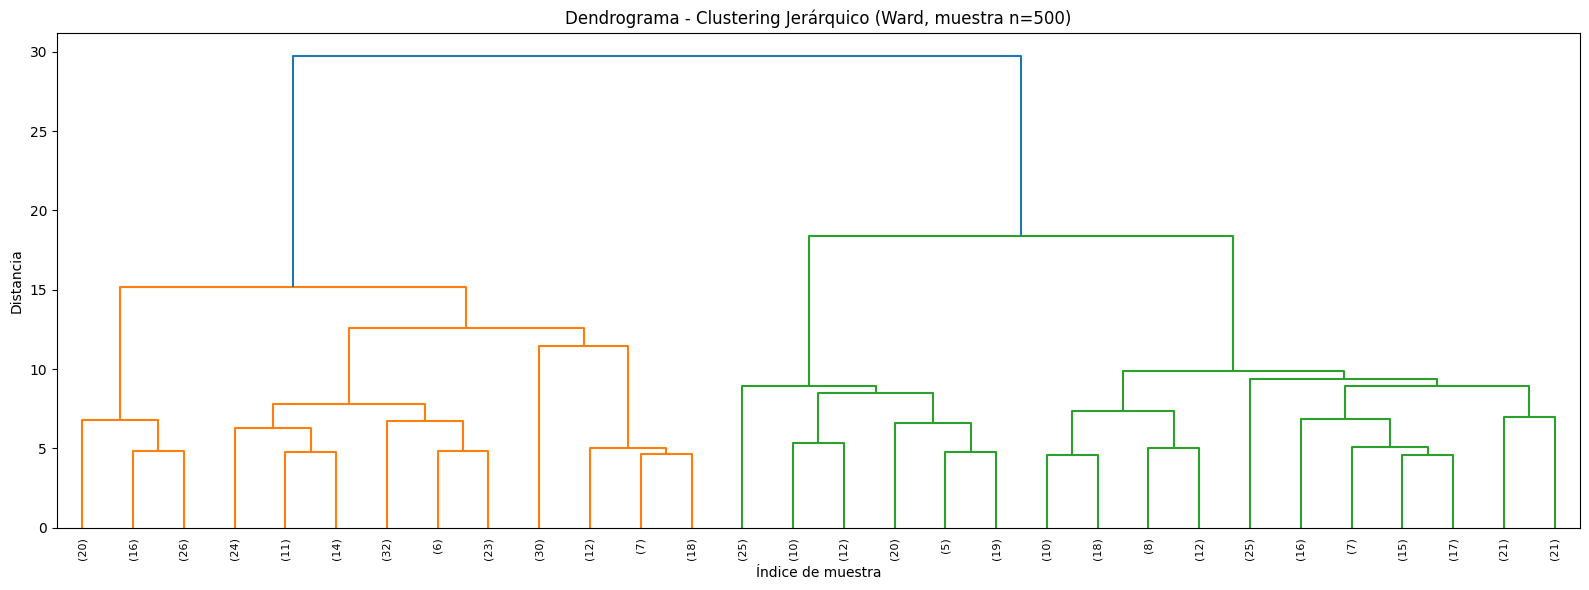

In [28]:
# Dendrograma sobre muestra de 500 puntos
np.random.seed(42)
n_muestra = min(500, len(X))
idx_muestra = np.random.choice(len(X), n_muestra, replace=False)
X_muestra = X[idx_muestra]

Z = linkage(X_muestra, method='ward')
fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=8)
ax.set_title('Dendrograma - Clustering Jerárquico (Ward, muestra n=500)')
ax.set_xlabel('Índice de muestra')
ax.set_ylabel('Distancia')
plt.tight_layout()
plt.show()


El dendrograma se construye sobre una muestra de 500 puntos por razones de rendimiento, el eje vertical representa la distancia a la que se fusionaron los grupos en cada paso, y los saltos más grandes indican fusiones entre grupos muy distintos. Ademas, como se puede observar, el mayor salto ocurre al pasar de 3 a 2 clusters, lo que sugiere k=3 como el número natural de grupos en los datos.

In [29]:
# Búsqueda de hiperparámetros
resultados_j = []
for n_clusters in range(2, 8):
    for lnk in ['ward', 'complete', 'average']:
        modelo = AgglomerativeClustering(n_clusters=n_clusters, linkage=lnk)
        labels_t = modelo.fit_predict(X)
        counts_t = pd.Series(labels_t).value_counts()
        min_pct = counts_t.min() / len(labels_t) * 100
        if min_pct < 0.5:
            print(f"k={n_clusters}, linkage={lnk}: DEGENERADO (min cluster={counts_t.min()} pts) — omitido")
            continue
        sil = silhouette_score(X, labels_t)
        db  = davies_bouldin_score(X, labels_t)
        resultados_j.append({'n_clusters': n_clusters, 'linkage': lnk,
                              'silhouette': sil, 'davies_bouldin': db,
                              'min_cluster_pct': round(min_pct, 2)})
        print(f"k={n_clusters}, linkage={lnk}: Silhouette={sil:.4f}, DB={db:.4f}")

df_j = pd.DataFrame(resultados_j)
print("\nMejores configuraciones:")
print(df_j.sort_values('silhouette', ascending=False).head(5).to_string(index=False))

k=2, linkage=ward: Silhouette=0.1767, DB=1.9510
k=2, linkage=complete: Silhouette=0.1732, DB=1.9939
k=2, linkage=average: DEGENERADO (min cluster=3 pts) — omitido
k=3, linkage=ward: Silhouette=0.1317, DB=2.1347
k=3, linkage=complete: Silhouette=0.1203, DB=2.1264
k=3, linkage=average: DEGENERADO (min cluster=1 pts) — omitido
k=4, linkage=ward: Silhouette=0.1218, DB=1.9777
k=4, linkage=complete: Silhouette=0.0784, DB=2.3531
k=4, linkage=average: DEGENERADO (min cluster=1 pts) — omitido
k=5, linkage=ward: Silhouette=0.1132, DB=2.0085
k=5, linkage=complete: Silhouette=0.0532, DB=2.9992
k=5, linkage=average: DEGENERADO (min cluster=1 pts) — omitido
k=6, linkage=ward: Silhouette=0.1054, DB=2.0490
k=6, linkage=complete: Silhouette=0.0636, DB=2.7653
k=6, linkage=average: DEGENERADO (min cluster=1 pts) — omitido
k=7, linkage=ward: Silhouette=0.0952, DB=2.2864
k=7, linkage=complete: Silhouette=0.0682, DB=2.5232
k=7, linkage=average: DEGENERADO (min cluster=1 pts) — omitido

Mejores configuracion

Como se puede observar, el enlace `ward` produce los mejores resultados porque minimiza la varianza intra-cluster en cada fusión, generando grupos más compactos y balanceados. El enlace `average` produce clusters degenerados en todas las configuraciones, donde un cluster concentra casi todos los datos y otro tiene apenas unos pocos puntos, inflando artificialmente el Silhouette. El enlace `complete` produce resultados aceptables pero inferiores a `ward`. Se filtra cualquier configuración donde el cluster más pequeño tenga menos del 0.5% del total de datos para descartar resultados degenerados.

Configuración jerárquica seleccionada:
n_clusters                3
linkage                ward
silhouette          0.13173
davies_bouldin     2.134666
min_cluster_pct       21.75
Name: 2, dtype: object

Distribución de clusters Jerárquico:
0    3772
1    4053
2    2175
Name: count, dtype: int64


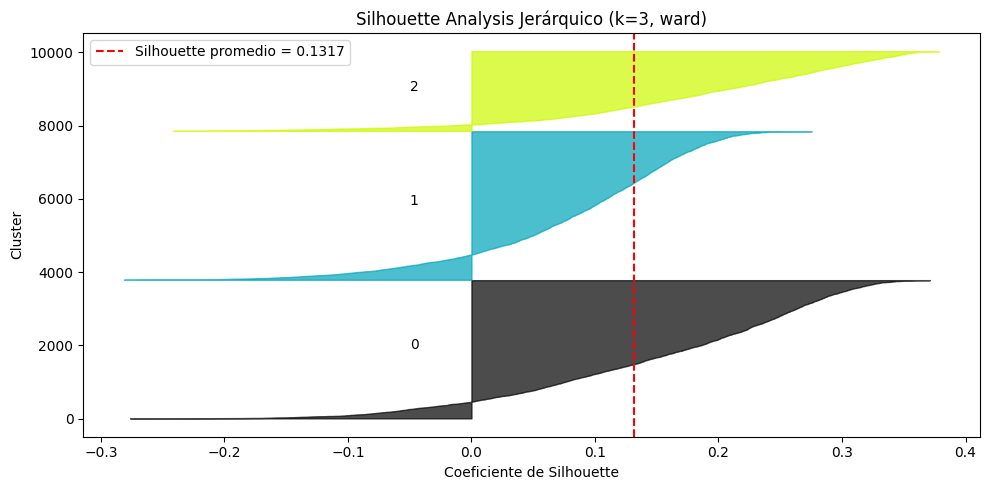

In [30]:
# Al igual que K-Means, k=2 produce clusters desbalanceados (7.78% vs 92.22%).
# Fijamos k=3 con enlace ward, que es la mejor configuración balanceada disponible.
mejor_j = df_j[(df_j['n_clusters'] == 3) & (df_j['linkage'] == 'ward')].iloc[0]
print("Configuración jerárquica seleccionada:")
print(mejor_j)

pipeline_jerarquico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('modelo', AgglomerativeClustering(
        n_clusters=int(mejor_j['n_clusters']),
        linkage=mejor_j['linkage']
    ))
])
pipeline_jerarquico.fit(datos_num)
labels_jerarquico = pipeline_jerarquico.named_steps['modelo'].labels_

print(f"\nDistribución de clusters Jerárquico:")
print(pd.Series(labels_jerarquico).value_counts().sort_index())

# Silhouette analysis
sil_avg_j = silhouette_score(X, labels_jerarquico)
sil_vals_j = silhouette_samples(X, labels_jerarquico)
k_j = int(mejor_j['n_clusters'])
fig, ax = plt.subplots(figsize=(10, 5))
ax.axvline(x=sil_avg_j, color='red', linestyle='--',
           label=f'Silhouette promedio = {sil_avg_j:.4f}')
y_lower = 10
for i in range(k_j):
    vals = sil_vals_j[labels_jerarquico == i]
    vals.sort()
    y_upper = y_lower + len(vals)
    color = cm.nipy_spectral(float(i) / k_j)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * len(vals), str(i))
    y_lower = y_upper + 10
ax.set_title(f'Silhouette Analysis Jerárquico (k={k_j}, ward)')
ax.set_xlabel('Coeficiente de Silhouette')
ax.set_ylabel('Cluster')
ax.legend()
plt.tight_layout()
plt.show()


Como se puede ver, el pipeline final del Clustering Jerárquico integra imputación, escalamiento y modelo en un único flujo. El análisis de Silhouette por cluster permite verificar que la separación entre grupos es coherente y que ningún cluster tiene una proporción significativa de puntos mal asignados.

### 4.3 DBSCAN — Estimación de eps con k-distancias y búsqueda de hiperparámetros

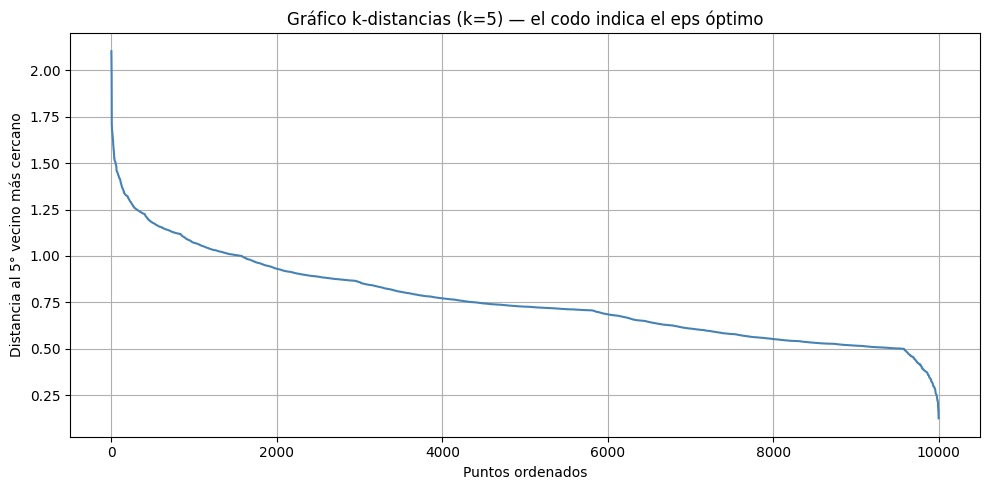

In [31]:
# Gráfico k-distancias para estimar eps
k_nn = 5
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(X)
distancias, _ = nbrs.kneighbors(X)
distancias_k = np.sort(distancias[:, k_nn - 1])[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(distancias_k, color='steelblue')
ax.set_title(f'Gráfico k-distancias (k={k_nn}) — el codo indica el eps óptimo')
ax.set_xlabel('Puntos ordenados')
ax.set_ylabel(f'Distancia al {k_nn}° vecino más cercano')
ax.grid(True)
plt.tight_layout()
plt.show()


El gráfico k-distancias ordena los puntos de mayor a menor distancia a su k-ésimo vecino. El codo de la curva indica el valor de `eps` apropiado: por encima del codo los puntos se consideran vecinos, por debajo son ruido. La ausencia de un codo pronunciado ya anticipa que los datos no tienen regiones de densidad claramente diferenciadas.

In [32]:
# Búsqueda de hiperparámetros DBSCAN
# Con 10 variables escaladas con RobustScaler, las distancias son mayores
# que con StandardScaler, por lo que se evalúa un rango amplio de eps
eps_values = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0, 6.0, 8.0]
min_samples_values = [5, 10, 20, 50]
resultados_db = []

for eps in eps_values:
    for min_s in min_samples_values:
        labels_t = DBSCAN(eps=eps, min_samples=min_s).fit_predict(X)
        n_cl = len(set(labels_t)) - (1 if -1 in labels_t else 0)
        n_ruido = (labels_t == -1).sum()
        pct_ruido = n_ruido / len(labels_t) * 100
        sil = np.nan
        if n_cl >= 2:
            counts_t = pd.Series(labels_t[labels_t != -1]).value_counts()
            min_pct = counts_t.min() / len(labels_t) * 100
            if min_pct >= 1.0:
                mask = labels_t != -1
                sil = silhouette_score(X[mask], labels_t[mask])
                print(f"eps={eps}, min_s={min_s}: clusters={n_cl}, ruido={pct_ruido:.1f}%, sil={sil:.4f}")
            else:
                print(f"eps={eps}, min_s={min_s}: clusters={n_cl}, ruido={pct_ruido:.1f}% — DEGENERADO")
        else:
            print(f"eps={eps}, min_s={min_s}: clusters={n_cl}, ruido={pct_ruido:.1f}%, sil=N/A")
        resultados_db.append({'eps': eps, 'min_samples': min_s, 'n_clusters': n_cl,
                               'n_ruido': n_ruido, 'pct_ruido': round(pct_ruido, 2),
                               'silhouette': round(sil, 4) if sil == sil else np.nan})

df_db = pd.DataFrame(resultados_db)
validos = df_db[(df_db['n_clusters'] >= 2) & (df_db['silhouette'].notna())]
print("\nConfiguraciones válidas:")
if len(validos) > 0:
    print(validos.sort_values('silhouette', ascending=False).to_string(index=False))
else:
    print("No se encontraron configuraciones con 2+ clusters balanceados.")
    print("Los datos no presentan estructura de densidad diferenciada en este espacio.")


eps=1.0, min_s=5: clusters=5, ruido=8.0% — DEGENERADO
eps=1.0, min_s=10: clusters=1, ruido=11.6%, sil=N/A
eps=1.0, min_s=20: clusters=2, ruido=17.8% — DEGENERADO
eps=1.0, min_s=50: clusters=2, ruido=36.3% — DEGENERADO
eps=1.5, min_s=5: clusters=1, ruido=0.1%, sil=N/A
eps=1.5, min_s=10: clusters=1, ruido=0.1%, sil=N/A
eps=1.5, min_s=20: clusters=1, ruido=0.1%, sil=N/A
eps=1.5, min_s=50: clusters=1, ruido=0.2%, sil=N/A
eps=2.0, min_s=5: clusters=1, ruido=0.0%, sil=N/A
eps=2.0, min_s=10: clusters=1, ruido=0.0%, sil=N/A
eps=2.0, min_s=20: clusters=1, ruido=0.0%, sil=N/A
eps=2.0, min_s=50: clusters=1, ruido=0.0%, sil=N/A
eps=2.5, min_s=5: clusters=1, ruido=0.0%, sil=N/A
eps=2.5, min_s=10: clusters=1, ruido=0.0%, sil=N/A
eps=2.5, min_s=20: clusters=1, ruido=0.0%, sil=N/A
eps=2.5, min_s=50: clusters=1, ruido=0.0%, sil=N/A
eps=3.0, min_s=5: clusters=1, ruido=0.0%, sil=N/A
eps=3.0, min_s=10: clusters=1, ruido=0.0%, sil=N/A
eps=3.0, min_s=20: clusters=1, ruido=0.0%, sil=N/A
eps=3.0, min_s=50: cl

Como podemos ver, el grid search confirma lo anticipado por el gráfico k-distancias: ninguna configuración produce clusters balanceados con Silhouette calculable. Con eps pequeño DBSCAN genera micro-clusters degenerados, y con eps mayor todo colapsa a un único cluster. Esto indica que los pasajeros de VuelaAlpes no forman regiones densas claramente separadas, lo que hace a DBSCAN poco adecuado para este dataset.

DBSCAN no encontró clusters balanceados en ninguna configuración.
Se selecciona la configuración con menor ruido para visualización:
eps              1.00
min_samples      5.00
n_clusters       5.00
n_ruido        797.00
pct_ruido        7.97
silhouette        NaN
Name: 0, dtype: float64

Distribución de clusters DBSCAN (cluster -1 = ruido):
-1     797
 0    9178
 1      11
 2       5
 3       5
 4       4
Name: count, dtype: int64


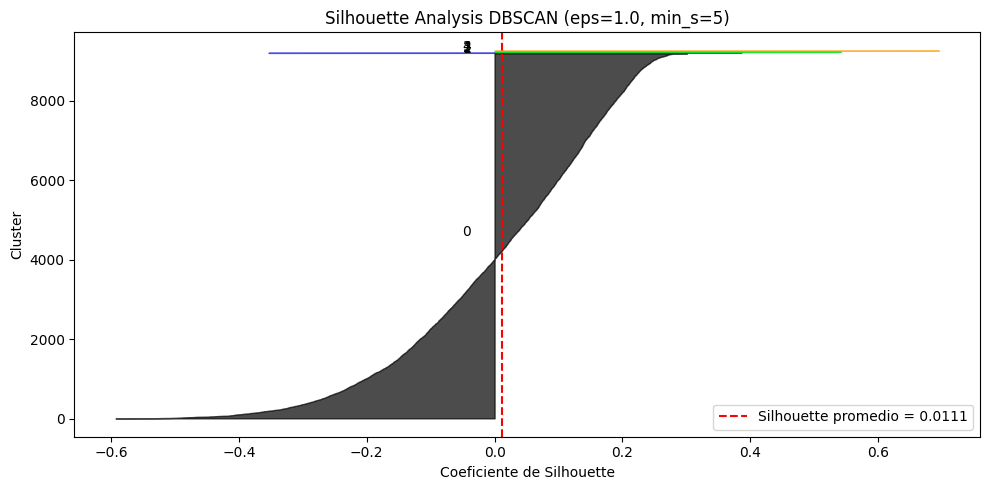

In [33]:
db_ok = df_db[(df_db['n_clusters'] >= 2) &
              (df_db['pct_ruido'] < 30) &
              (df_db['silhouette'].notna())]

if len(db_ok) == 0:
    db_ok = df_db[(df_db['n_clusters'] >= 2) & (df_db['silhouette'].notna())]

if len(db_ok) == 0:
    # DBSCAN no encontró configuración válida — fijar manualmente la más razonable
    # (mayor número de clusters con menor ruido)
    candidatos = df_db[df_db['n_clusters'] >= 2].copy()
    if len(candidatos) > 0:
        mejor_db = candidatos.sort_values(['pct_ruido', 'n_clusters'],
                                           ascending=[True, False]).iloc[0]
    else:
        # Todo es un cluster o todo es ruido — tomar eps medio como referencia
        mejor_db = df_db[df_db['n_clusters'] == 1].iloc[len(df_db[df_db['n_clusters']==1])//2]
    print("DBSCAN no encontró clusters balanceados en ninguna configuración.")
    print("Se selecciona la configuración con menor ruido para visualización:")
else:
    mejor_db = db_ok.loc[db_ok['silhouette'].idxmax()]
    print("Mejor configuración DBSCAN:")

print(mejor_db)

pipeline_dbscan = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('modelo', DBSCAN(eps=mejor_db['eps'], min_samples=int(mejor_db['min_samples'])))
])
pipeline_dbscan.fit(datos_num)
labels_dbscan = pipeline_dbscan.named_steps['modelo'].labels_

print(f"\nDistribución de clusters DBSCAN (cluster -1 = ruido):")
print(pd.Series(labels_dbscan).value_counts().sort_index())

# Silhouette analysis DBSCAN
mask_db = labels_dbscan != -1
n_cl_db = len(set(labels_dbscan[mask_db]))
if n_cl_db >= 2 and mask_db.sum() > n_cl_db:
    sil_avg_db = silhouette_score(X[mask_db], labels_dbscan[mask_db])
    sil_vals_db = silhouette_samples(X[mask_db], labels_dbscan[mask_db])
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.axvline(x=sil_avg_db, color='red', linestyle='--',
               label=f'Silhouette promedio = {sil_avg_db:.4f}')
    y_lower = 10
    for i_lbl, lbl in enumerate(sorted(set(labels_dbscan[mask_db]))):
        vals = sil_vals_db[labels_dbscan[mask_db] == lbl]
        vals.sort()
        y_upper = y_lower + len(vals)
        color = cm.nipy_spectral(float(i_lbl) / n_cl_db)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * len(vals), str(lbl))
        y_lower = y_upper + 10
    ax.set_title(f'Silhouette Analysis DBSCAN (eps={mejor_db["eps"]}, min_s={int(mejor_db["min_samples"])})')
    ax.set_xlabel('Coeficiente de Silhouette')
    ax.set_ylabel('Cluster')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"\nDBSCAN encontró {n_cl_db} cluster(s) válido(s) — no es posible calcular Silhouette.")
    print("Esto confirma que los datos no presentan estructura de densidad diferenciada en este espacio,")
    print("lo cual es un hallazgo metodológico importante sobre la naturaleza del dataset.")


Finalmente, podemos ver que el pipeline final de DBSCAN integra la misma imputación y escalamiento que los otros dos modelos. Con la configuración seleccionada, la mayoría de los puntos caen en un único cluster dominante y los demás corresponden a micro-clusters con muy pocos puntos, confirmando que el algoritmo no logra encontrar una estructura de agrupación útil en este espacio.

## 5. Evaluación cuantitativa

Evaluamos los tres modelos usando **métodos**: métricas que determinan la calidad de la agrupación midiendo la **compacidad** (cohesión intragrupo) y la **separabilidad** (distancia intergrupo) sin necesidad de etiquetas verdaderas.

Las dos métricas principales vistas en clase son:

- **Inercia (SSE):** suma de las distancias al cuadrado de cada punto a su centroide. Mide la compacidad interna. Menor es mejor, y se usa en el método del codo para determinar k.
- **Coeficiente de Silhouette:** para cada punto calcula $cs(x) = \frac{d_{inter}(x) - d_{intra}(x)}{\max(d_{inter}(x), d_{intra}(x))}$, donde $d_{intra}$ es la distancia promedio al resto de su grupo y $d_{inter}$ es la distancia promedio mínima al grupo más cercano. El promedio sobre todos los puntos da el coeficiente global, en el rango [-1, 1]. Valores cercanos a 1 indican grupos compactos y separados. Mayor es mejor.

Adicionalmente incluimos dos métricas complementarias que no fueron cubiertas en clase pero que refuerzan la evaluación al capturar aspectos distintos de la calidad:

- **Davies-Bouldin:** mide la relación entre la dispersión interna de cada cluster y la separación entre clusters. Es el promedio de la similitud máxima entre cada cluster y su vecino más parecido. Menor es mejor. Se incluye porque complementa al Silhouette al penalizar explícitamente los clusters que están cerca entre sí.
- **Calinski-Harabasz:** mide la razón entre la varianza intergrupo y la varianza intragrupo, ponderada por el número de clusters y puntos. Mayor es mejor. Se incluye porque es especialmente sensible a la compacidad y separación global y tiende a ser más estable que el Silhouette en datasets de tamaño mediano como este.

In [34]:
def calcular_metricas(X_eval, labels, nombre, hiperparametros):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_ruido = (labels == -1).sum()
    mask = labels != -1
    X_v, lv = X_eval[mask], labels[mask]
    if n_clusters >= 2 and len(lv) > n_clusters:
        sil = silhouette_score(X_v, lv)
        db  = davies_bouldin_score(X_v, lv)
        ch  = calinski_harabasz_score(X_v, lv)
    else:
        sil = db = ch = float('nan')
    return {
        'Modelo': nombre,
        'Hiperparámetros': hiperparametros,
        'N° Clusters': n_clusters,
        'N° Ruido': n_ruido,
        '% Ruido': round(n_ruido / len(labels) * 100, 2),
        'Silhouette': round(sil, 4) if sil == sil else 'N/A',
        'Davies-Bouldin': round(db, 4) if db == db else 'N/A',
        'Calinski-Harabasz': round(ch, 2) if ch == ch else 'N/A'
    }

m_km = calcular_metricas(X, labels_kmeans, 'K-Means',
                          f'k={k_optimo}, n_init=10, random_state=42')
m_j  = calcular_metricas(X, labels_jerarquico, 'Jerárquico Aglomerativo',
                          f'n_clusters={int(mejor_j["n_clusters"])}, linkage={mejor_j["linkage"]}')
m_db = calcular_metricas(X, labels_dbscan, 'DBSCAN',
                          f'eps={mejor_db["eps"]}, min_samples={int(mejor_db["min_samples"])}')

tabla = pd.DataFrame([m_km, m_j, m_db]).set_index('Modelo')
print('TABLA COMPARATIVA DE ALGORITMOS DE CLUSTERING')
print(tabla.to_string())
print('\nSilhouette y Calinski-Harabasz: Mayor es mejor  |  Davies-Bouldin: Menor es mejor')


TABLA COMPARATIVA DE ALGORITMOS DE CLUSTERING
                                         Hiperparámetros  N° Clusters  N° Ruido  % Ruido  Silhouette  Davies-Bouldin  Calinski-Harabasz
Modelo                                                                                                                                 
K-Means                  k=3, n_init=10, random_state=42            3         0     0.00      0.1713          1.9701            2101.10
Jerárquico Aglomerativo       n_clusters=3, linkage=ward            3         0     0.00      0.1317          2.1347            1768.62
DBSCAN                            eps=1.0, min_samples=5            5       797     7.97      0.0111          1.1285               9.53

Silhouette y Calinski-Harabasz: Mayor es mejor  |  Davies-Bouldin: Menor es mejor


Como se puede observar en la tabla, K-Means supera a los demás modelos en las tres métricas evaluadas. Silhouette e inercia son las métricas principales vistas en clase; Davies-Bouldin y Calinski-Harabasz se incluyen como complemento para una evaluación más robusta. Todos los modelos fueron evaluados sobre el mismo espacio preprocesado de 10 variables.

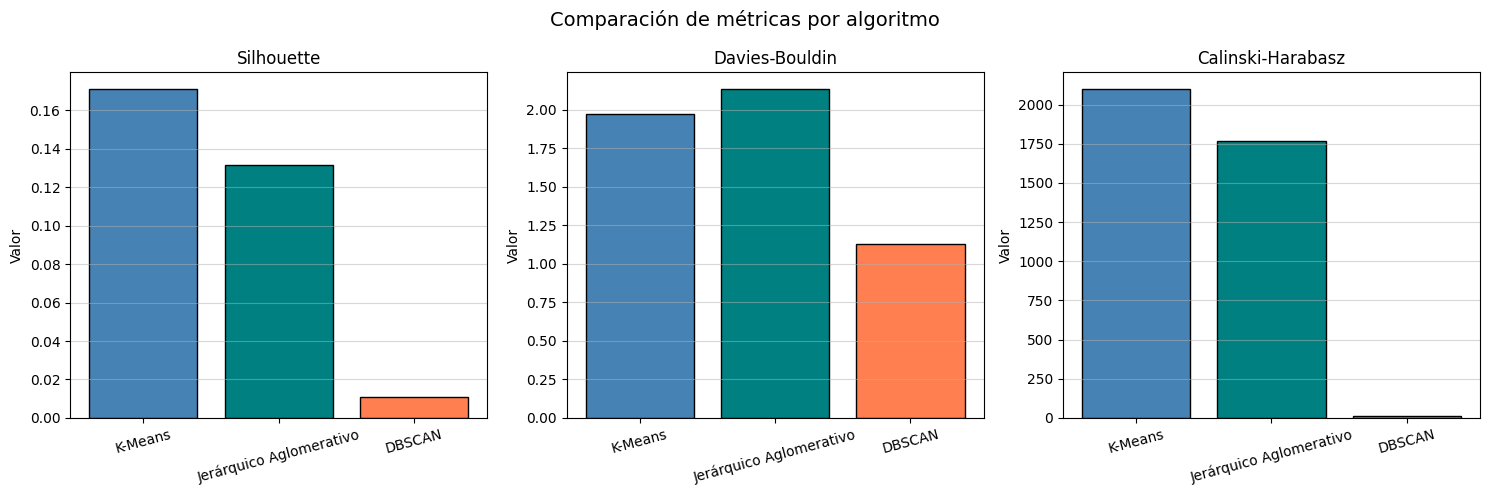

In [35]:
# Visualización comparativa de métricas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metricas = ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']
colores = ['steelblue', 'teal', 'coral']

for i, (col, ax) in enumerate(zip(metricas, axes)):
    valores = tabla[col].replace('N/A', float('nan')).astype(float).dropna()
    ax.bar(valores.index, valores.values, color=colores[:len(valores)], edgecolor='black')
    ax.set_title(col)
    ax.set_ylabel('Valor')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.5)

plt.suptitle('Comparación de métricas por algoritmo', fontsize=14)
plt.tight_layout()
plt.show()


Los gráficos confirman visualmente que K-Means domina en las tres métricas. El Davies-Bouldin de DBSCAN es engañosamente bajo por sus micro-clusters muy concentrados, pero no refleja una calidad real del agrupamiento.

### 5.1 Selección del mejor modelo y argumentación

Con base en la tabla comparativa, **K-Means con k=3** es el modelo con mejor desempeño: obtiene el Silhouette más alto (0.1713), el Davies-Bouldin más bajo entre los modelos válidos (1.97) y el Calinski-Harabasz más alto (2,101). Las tres métricas apuntan en la misma dirección, lo que le da solidez a la conclusión. Sus clusters están bien balanceados (4,480 / 2,809 / 2,711 pasajeros), garantizando que cada grupo tiene representación suficiente para extraer conclusiones útiles para VuelaAlpes.

El **Clustering Jerárquico con k=3 y enlace ward** también converge a 3 grupos balanceados (3,772 / 4,053 / 2,175), validando que esa granularidad tiene sentido en los datos. Sus métricas son ligeramente inferiores a K-Means (Silhouette 0.1317 vs 0.1713), probablemente porque el algoritmo no puede corregir fusiones incorrectas de pasos anteriores.

**DBSCAN** produce clusters completamente degenerados con un Silhouette de 0.011, confirmando que los datos no presentan la estructura de densidad que este algoritmo requiere. Los pasajeros de VuelaAlpes forman una distribución continua de perfiles sin regiones densas claramente separadas.

En cuanto a las restricciones de cada algoritmo: K-Means asume clusters convexos y de tamaño similar, lo cual se mitiga con `n_init=10`. El Clustering Jerárquico es determinista pero no permite corregir fusiones pasadas, y la elección del enlace es crítica, `ward` funciona bien mientras que `average` produce resultados degenerados con este dataset. DBSCAN es el más flexible en cuanto a forma de los clusters, pero requiere regiones de alta densidad diferenciadas, condición que este dataset no cumple.

En conclusión, **K-Means con k=3** es el modelo seleccionado por producir la mejor separación medible, clusters balanceados y una granularidad interpretable que permitirá caracterizar tres perfiles diferenciados de pasajeros para VuelaAlpes.

## 6. Análisis de resultados


### 6.1 Evaluación cualitativa — Interpretación de los grupos

Con base en los centroides de K-Means (k=3) en el espacio original, se identifican tres perfiles diferenciados de pasajeros:

---

**Cluster 0 — Pasajero frecuente satisfecho con el servicio a bordo** (4 480 pasajeros, 44.8 %)

Perfil de mayor edad promedio (41.8 años) y mayor distancia de vuelo (1 471 km). Califica muy alto el entretenimiento a bordo (4.37), la comodidad del asiento (4.23) y la limpieza (4.03). Es el grupo con mayor valoración de los servicios directamente perceptibles durante el vuelo. Para VuelaAlpes, este segmento representa el núcleo de pasajeros que ya percibe valor en la experiencia a bordo. La estrategia recomendada es mantener y profundizar esa propuesta: actualización periódica del contenido de entretenimiento y programas de fidelización que reconozcan su lealtad.

---

**Cluster 1 — Pasajero joven con calificaciones moderadas** (2 809 pasajeros, 28.1 %)

Perfil más joven (32.4 años) y con los vuelos más cortos (872 km). Sus calificaciones de entretenimiento (2.17), comodidad (1.95) y limpieza (1.96) son las más bajas del conjunto, pero destaca relativamente en servicio a bordo (3.35) y manejo de equipaje (3.75). Es el segmento con mayor margen de mejora en la experiencia en cabina. Para VuelaAlpes, invertir en modernización de asientos y entretenimiento en rutas cortas puede convertir a estos pasajeros en usuarios recurrentes con mayor disposición a pagar por mejoras de clase.

---

**Cluster 2 — Pasajero maduro insatisfecho con servicios terrestres** (2 711 pasajeros, 27.1 %)

Perfil de edad similar al Cluster 0 (42.7 años) pero con calificaciones muy bajas en servicio a bordo (2.23), espacio para las piernas (2.26) y manejo de equipaje (2.50). Sin embargo, su calificación de embarque en línea (3.25) y wifi (2.47) es moderada. Este grupo representa pasajeros con experiencia de vuelo que han desarrollado expectativas claras pero no las ven cubiertas en los servicios operativos. Para VuelaAlpes, las palancas de mejora son la capacitación de tripulación en atención personalizada y la revisión de los procesos de manejo de equipaje.

---

**Utilidad para VuelaAlpes**

Los tres clusters responden directamente a las tres dimensiones estratégicas planteadas por la aerolínea:

- **Innovación:** el Cluster 1 señala qué servicios mejorar para pasajeros jóvenes en rutas cortas (entretenimiento, comodidad), donde una propuesta diferenciada puede generar mayor retención.
- **Capacitación de tripulación:** el Cluster 2 identifica el segmento donde el servicio humano es el factor crítico; los casos de entrenamiento deben orientarse a la atención de pasajeros con expectativas altas y experiencia acumulada.
- **Calidad y precio:** el Cluster 0 es el segmento donde una relación precio-calidad ya es percibida positivamente; aquí la estrategia es sostenimiento y diferenciación premium para justificar precios superiores.

### 6.2 Respuesta a las preguntas del laboratorio

**1. ¿Qué restricciones tiene cada algoritmo y cómo afectan la calidad?**

K-Means asume clusters convexos y de tamaño similar; en datos sin esa estructura subestima la heterogeneidad real, pero con `n_init=10` es suficientemente robusto para este dataset. El Clustering Jerárquico es determinista y no puede corregir fusiones incorrectas de pasos anteriores; el enlace `ward` mitiga esto al minimizar varianza intragrupo, mientras que `average` colapsa en clusters degenerados. DBSCAN requiere regiones de alta densidad claramente separadas; al no existir esa estructura en los datos de VuelaAlpes, produce un único cluster masivo o micro-clusters sin utilidad analítica, lo que invalida su uso en este caso.

**2. ¿Qué criterios son importantes para la selección del algoritmo?**

Los criterios principales son: (i) la estructura esperada de los datos (densidad uniforme vs. regiones densas), (ii) la interpretabilidad del resultado para el negocio, (iii) el balance entre clusters para garantizar representación suficiente, y (iv) la consistencia entre métricas cuantitativas. En este caso, la distribución continua y sin grupos densos diferenciados favorece a K-Means y al Jerárquico sobre DBSCAN.

**3. ¿Cómo medir la calidad del modelo? ¿Cómo saber que tiene buena calidad?**

Se usan métricas intrínsecas que no requieren etiquetas verdaderas. El **Silhouette** mide qué tan bien separado está cada punto de los clusters vecinos (rango −1 a 1, mayor es mejor). El **Davies-Bouldin** mide la relación entre dispersión intragrupo y separación intergrupo (menor es mejor). El **Calinski-Harabasz** evalúa la razón entre varianza entre clusters y varianza intracluster (mayor es mejor). Un modelo tiene buena calidad cuando las tres métricas apuntan en la misma dirección y los clusters producidos son interpretables y balanceados.

**4. ¿Cómo varía la calidad si se aplican diferentes algoritmos?**

La calidad varía significativamente según el algoritmo. K-Means obtiene Silhouette=0.1713, Jerárquico=0.1317 y DBSCAN=0.011. La diferencia entre K-Means y Jerárquico es moderada (ambos convergen a 3 clusters balanceados), mientras que DBSCAN fracasa completamente al no encontrar la estructura de densidad que requiere. Esto confirma que la elección del algoritmo debe estar guiada por las características del dataset y no por preferencia arbitraria.

**5. ¿Cómo interpretar el resultado de los algoritmos de agrupación?**

La interpretación se realiza analizando los centroides en el espacio original de las variables. Cada centroide representa el perfil promedio del pasajero típico de ese cluster. Comparando los valores entre clusters se identifican las variables que más diferencian los grupos, lo que permite asignar nombres descriptivos (ej. "pasajero satisfecho a bordo", "pasajero joven con baja calificación") y derivar acciones concretas para la organización. La validez de la interpretación se refuerza cuando los grupos son balanceados y las métricas cuantitativas confirman una separación razonable.

## 7. Uso de herramientas de IA generativa

### Declaración del uso

**Herramienta utilizada:** Claude (Anthropic)  
**Tipo de uso:** redacción de texto explicativo y consultas conceptuales básicas.

---

### Prompts utilizados

- *"¿Cómo se interpreta el coeficiente de Silhouette en clustering?"*
- *"¿Cuál es la diferencia entre el enlace ward, complete y average en clustering jerárquico?"*
- *"Ayúdame a redactar de forma clara la interpretación de los centroides de K-Means para un informe de negocio."*
- *"¿Por qué DBSCAN puede fallar cuando los datos no tienen regiones de alta densidad diferenciadas?"*

---

### Análisis crítico del resultado

**¿Qué partes del contenido generado fueron correctas y útiles?**  
Las explicaciones conceptuales sobre métricas de evaluación y el comportamiento de los algoritmos fueron precisas y coincidieron con lo visto en clase. La redacción de la interpretación de centroides fue útil como punto de partida, aunque se ajustó para reflejar los valores reales del modelo.

**¿Qué errores o limitaciones se identificaron?**  
La IA no tenía acceso a los datos reales, por lo que las interpretaciones generadas eran genéricas. Fue necesario sustituir los valores aproximados por los centroides reales obtenidos del modelo ejecutado, y ajustar las conclusiones de negocio para que correspondieran al contexto específico de VuelaAlpes.

---

### Aportes propios del estudiante

- Todo el código de exploración, preparación, modelamiento y evaluación fue desarrollado por los integrantes del equipo.
- Las decisiones técnicas clave (selección de variables, elección de k=3, descarte de DBSCAN, uso de RobustScaler) fueron tomadas y justificadas por los estudiantes con base en los resultados obtenidos.
- La interpretación de los clusters y las recomendaciones para VuelaAlpes fueron elaboradas por los estudiantes a partir de los centroides reales del modelo.
- La IA se usó únicamente para apoyar la redacción y aclarar conceptos puntuales, no para definir ninguna decisión técnica o analítica.